# scOPE — PAAD (TCGA Pancreatic Adenocarcinoma)

1. **Phase 1** — TCGA PAAD bulk RNA-seq + MC3 mutations.
2. **Phase 2** — Peng et al. 2019 (Cell Research) PAAD scRNA-seq
   (GSE155698 / GSE111672, ~24 000 cells, 24 tumours).

**Data notes:**
- Bulk: Xena HiSeqV2_PANCAN, log2(norm_count+1). Primary (01) + normal (11).
- SC: GSE111672 (Peng et al.) — `GSE111672_PAAD_final_list_log2_normalized.txt.gz`.
  Data is log2(CPM+1) — no further normalisation applied.
- KRAS is mutated in ~90% of PAAD making it the dominant signal; the model
  will primarily learn the transcriptional consequences of KRAS-driven
  oncogenesis (MAPK, metabolic reprogramming).


## 1. Imports & paths

In [1]:
import os
import subprocess

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests

from scope import BulkPipeline, SingleCellPipeline
from scope.visualization import (
    compute_umap,
    plot_mutation_probabilities,
    plot_scree,
    plot_mutation_heatmap,
)

mpl.rcParams['figure.dpi']    = 100
mpl.rcParams['savefig.dpi']   = 300
mpl.rcParams['figure.figsize'] = (10, 6)


In [2]:
BASE_DIR   = "/home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data"
BULK_DIR   = os.path.join(BASE_DIR, "TCGA_PAAD")
SC_DIR     = os.path.join(BASE_DIR, "PAAD_scRNA")
MODELS_DIR = os.path.join(BASE_DIR, "..", "models", "PAAD")
CANCER_TAG = "PAAD"

for d in [BULK_DIR, SC_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

paad_expr_path = os.path.join(BULK_DIR, "TCGA_PAAD_HiSeqV2_PANCAN.tsv.gz")
mc3_path       = os.path.join(BULK_DIR, "mc3.v0.2.8.PUBLIC.xena.gz")
sc_expr_path   = os.path.join(SC_DIR,   "GSE111672_PAAD_log2norm.txt.gz")
sc_meta_path   = os.path.join(SC_DIR,   "GSE111672_PAAD_metadata.txt.gz")


## 2. Download raw data

In [3]:
XENA_BASE = "https://tcga.xenahubs.net/download"
if os.path.exists(paad_expr_path):
    print(f"  already present -- {os.path.basename(paad_expr_path)}")
else:
    print("  downloading TCGA PAAD expression ...")
    r = requests.get(f"{XENA_BASE}/TCGA.PAAD.sampleMap/HiSeqV2_PANCAN.gz",
                     stream=True, timeout=300)
    r.raise_for_status()
    with open(paad_expr_path, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print(f"  done -> {paad_expr_path}")


  downloading TCGA PAAD expression ...
  done -> /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/TCGA_PAAD/TCGA_PAAD_HiSeqV2_PANCAN.tsv.gz


In [4]:
# -- MC3 PanCanAtlas MAF -- all TCGA cancer types, one file (~200 MB) -------
# Check sibling directories before downloading to avoid re-fetching.
_mc3_alts = [
    os.path.join(BASE_DIR, sib, "mc3.v0.2.8.PUBLIC.xena.gz")
    for sib in ["TCGA_CRC", "TCGA_SKCM", "TCGA_BRCA", "TCGA_LUAD",
                "TCGA_GBM", "TCGA_PAAD", "TCGA_LIHC", "TCGA_LAML"]
]
for _alt in _mc3_alts:
    if not os.path.exists(mc3_path) and os.path.exists(_alt):
        import shutil; shutil.copy(_alt, mc3_path)
        print(f"  copied MC3 from {os.path.dirname(_alt)}")
        break

if not os.path.exists(mc3_path):
    print("Downloading MC3 MAF (~200 MB) ...")
    r = requests.get(
        "https://pancanatlas.xenahubs.net/download/mc3.v0.2.8.PUBLIC.xena.gz",
        stream=True, timeout=600,
    )
    r.raise_for_status()
    with open(mc3_path, "wb") as fh:
        for chunk in r.iter_content(1 << 20):
            fh.write(chunk)
    print(f"  done -> {mc3_path}")
else:
    print(f"  already present -- {os.path.basename(mc3_path)}")


  copied MC3 from /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/TCGA_CRC
  already present -- mc3.v0.2.8.PUBLIC.xena.gz


In [7]:
# Correct accession: GSE111672 is Moffit et al. 2018 -- two PDAC inDrop samples
GEO_FTP = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE111nnn/GSE111672/suppl"

sc_pdacA_path = os.path.join(SC_DIR, "GSE111672_PDAC-A-indrop-filtered-expMat.txt.gz")
sc_pdacB_path = os.path.join(SC_DIR, "GSE111672_PDAC-B-indrop-filtered-expMat.txt.gz")

for dest, fname in [
    (sc_pdacA_path, "GSE111672_PDAC-A-indrop-filtered-expMat.txt.gz"),
    (sc_pdacB_path, "GSE111672_PDAC-B-indrop-filtered-expMat.txt.gz"),
]:
    if os.path.exists(dest):
        print(f"  already present -- {fname}")
    else:
        print(f"  downloading {fname} ...")
        _download_ncbi(f"{GEO_FTP}/{fname}", dest)
        print(f"  done -> {dest}")
        

  downloading GSE111672_PDAC-A-indrop-filtered-expMat.txt.gz ...



     0K .......... .......... .......... .......... ..........  1%  371K 10s
    50K .......... .......... .......... .......... ..........  2%  750K 7s
   100K .......... .......... .......... .......... ..........  3% 30.5M 5s
   150K .......... .......... .......... .......... ..........  5%  769K 5s
   200K .......... .......... .......... .......... ..........  6% 60.2M 4s
   250K .......... .......... .......... .......... ..........  7% 82.5M 3s
   300K .......... .......... .......... .......... ..........  9%  837K 3s
   350K .......... .......... .......... .......... .......... 10% 9.29M 3s
   400K .......... .......... .......... .......... .......... 11%  122M 2s
   450K .......... .......... .......... .......... .......... 13%  150M 2s
   500K .......... .......... .......... .......... .......... 14%  121M 2s
   550K .......... .......... .......... .......... .......... 15%  181M 2s
   600K .......... .......... .......... .......... .......... 17%  127M 2s
   650K ..

  done -> /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/PAAD_scRNA/GSE111672_PDAC-A-indrop-filtered-expMat.txt.gz
  downloading GSE111672_PDAC-B-indrop-filtered-expMat.txt.gz ...



     0K .......... .......... .......... .......... ..........  1%  135K 22s
    50K .......... .......... .......... .......... ..........  3%  171K 19s
   100K .......... .......... .......... .......... ..........  5%  150K 19s
   150K .......... .......... .......... .......... ..........  6%  376K 16s
   200K .......... .......... .......... .......... ..........  8%  250K 15s
   250K .......... .......... .......... .......... .......... 10%  375K 13s
   300K .......... .......... .......... .......... .......... 11%  376K 12s
   350K .......... .......... .......... .......... .......... 13%  376K 11s
   400K .......... .......... .......... .......... .......... 15%  376K 10s
   450K .......... .......... .......... .......... .......... 16%  748K 10s
   500K .......... .......... .......... .......... .......... 18%  376K 9s
   550K .......... .......... .......... .......... .......... 20%  746K 8s
   600K .......... .......... .......... .......... .......... 21%  378K 8s
 

  done -> /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/PAAD_scRNA/GSE111672_PDAC-B-indrop-filtered-expMat.txt.gz


......... .......... .......... 98% 22.5M 0s
  2950K .......... .......... .......... .......              100% 31.4M=4.1s

## 3. Load & prepare bulk RNA-seq

In [8]:
def load_xena_expression(path, cohort, type_map=None):
    """Load Xena HiSeqV2_PANCAN -> samples x genes AnnData."""
    if type_map is None:
        type_map = {"01": "tumor", "11": "normal"}
    df = pd.read_csv(path, sep="\t", index_col=0).T
    keep = df.index.str[13:15].isin(type_map)
    df   = df[keep]
    sample_type = df.index.str[13:15].map(type_map)
    adata = ad.AnnData(
        X   = df.values.astype(np.float32),
        obs = pd.DataFrame({"cohort": cohort, "sample_type": sample_type.values},
                           index=df.index),
        var = pd.DataFrame(index=df.columns),
    )
    for st, label in type_map.items():
        n = (sample_type == label).sum()
        print(f"  {cohort} {label} : {n}")
    return adata


In [9]:
adata_bulk = load_xena_expression(paad_expr_path, "PAAD")
adata_bulk.var_names_make_unique()
print(f"Bulk : {adata_bulk.n_obs} x {adata_bulk.n_vars}")


  PAAD tumor : 178
  PAAD normal : 4
Bulk : 182 x 20530


## 4. Build mutation label matrix

In [10]:
PAAD_GENES = [
    "KRAS",     # ~90% -- codons 12/13
    "TP53",     # ~75%
    "CDKN2A",   # ~50% -- p16/p14ARF
    "SMAD4",    # ~30% -- DPC4; metastasis-associated
    "ARID1A",
    "RNF43",    # WNT pathway; RSPO3/2 fusions common when WT
    "KDM6A",
    "GNAS",     # ~8% -- mainly IPMN-associated
    "KMT2D",    # MLL2
    "MAP2K4",
    "TGFBR2",
    "ROBO2",
    "ATM",
    "BRCA2",    # ~7% -- germline & somatic
    "STK11",
]
PAAD_GENES = list(dict.fromkeys(PAAD_GENES))
print(f"Targeting {len(PAAD_GENES)} PAAD driver genes")


Targeting 15 PAAD driver genes


In [11]:
KEEP_CLASSES = {
    "Missense_Mutation", "Nonsense_Mutation", "Frame_Shift_Del",
    "Frame_Shift_Ins", "In_Frame_Del", "In_Frame_Ins",
    "Splice_Site", "Translation_Start_Site", "Nonstop_Mutation",
}


In [12]:
# -- Filter MC3 to this cancer by matching against bulk 15-char barcodes --
mc3 = pd.read_csv(mc3_path, sep="\t", low_memory=False)
mc3 = mc3.rename(columns={
    "sample": "Tumor_Sample_Barcode",
    "effect": "Variant_Classification",
    "gene":   "Hugo_Symbol",
})
bulk_15_set   = set(adata_bulk.obs_names.str[:15])
mc3["sample_id"] = mc3["Tumor_Sample_Barcode"].str[:15]
maf_cancer    = mc3[mc3["sample_id"].isin(bulk_15_set)].copy()
print(f"Cancer rows (pre-filter) : {len(maf_cancer):,}   "
      f"samples: {maf_cancer['sample_id'].nunique()}")

maf_cancer = maf_cancer[maf_cancer["Variant_Classification"].isin(KEEP_CLASSES)]
maf_all    = maf_cancer[["sample_id", "Hugo_Symbol"]].dropna()
print(f"After coding filter      : {len(maf_all):,} variants   "
      f"{maf_all['sample_id'].nunique()} samples")


Cancer rows (pre-filter) : 30,451   samples: 170
After coding filter      : 20,026 variants   168 samples


In [13]:
mut_matrix = (
    maf_all[["sample_id", "Hugo_Symbol"]].drop_duplicates()
    .assign(mutated=1)
    .pivot_table(index="sample_id", columns="Hugo_Symbol",
                 values="mutated", fill_value=0)
)
mut_matrix.columns.name = None; mut_matrix.index.name = None
genes_present = [g for g in PAAD_GENES if g in mut_matrix.columns]
mutation_labels_raw = mut_matrix[genes_present]
is_normal = adata_bulk.obs["sample_type"] == "normal"
has_mc3   = adata_bulk.obs_names.str[:15].isin(mutation_labels_raw.index)
keep_mask = has_mc3 | is_normal.values
adata_bulk = adata_bulk[keep_mask].copy()
adata_bulk.obs["barcode_15"] = adata_bulk.obs_names.str[:15]
mut_re = mutation_labels_raw.copy()
mut_re.index = mut_re.index.str[:15]
mut_re = mut_re[~mut_re.index.duplicated(keep="first")]
mutation_labels = mut_re.reindex(adata_bulk.obs["barcode_15"]).fillna(0).astype(int)
mutation_labels.index = adata_bulk.obs_names
print(f"Mutation matrix : {mutation_labels.shape}")
tmask = adata_bulk.obs["sample_type"] != "normal"
print(mutation_labels[tmask].sum().sort_values(ascending=False).head(15))


Mutation matrix : (172, 15)
KRAS      111
TP53      103
SMAD4      36
CDKN2A     34
RNF43      11
GNAS        9
ARID1A      8
TGFBR2      8
KMT2D       7
ATM         7
KDM6A       6
MAP2K4      4
ROBO2       4
STK11       4
BRCA2       2
dtype: int64


## 5. Load single-cell data — Peng et al. 2019 (GSE111672)

In [19]:
adatas = []
for path, sample in [(sc_pdacA_path, "PDAC-A"), (sc_pdacB_path, "PDAC-B")]:
    df = pd.read_csv(path, sep="\t", index_col=0)   # genes x cells
    df.index = pd.io.common._maybe_convert_index(df.index) if False else df.index
    # Deduplicate gene names before building AnnData
    df = df[~df.index.duplicated(keep="first")]
    print(f"  {sample} : {df.shape[1]} cells x {df.shape[0]} genes (after dedup)")
    a  = ad.AnnData(
        X   = df.values.T.astype(np.float32),
        obs = pd.DataFrame({"sample": sample}, index=df.columns),
        var = pd.DataFrame(index=df.index),
    )
    adatas.append(a)

adata_sc = ad.concat(adatas, join="inner")
adata_sc.obs_names_make_unique()
print(f"\nCombined : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")
print(f"Value range: {adata_sc.X.min():.2f} -- {adata_sc.X.max():.2f}")


  PDAC-A : 1926 cells x 19736 genes (after dedup)
  PDAC-B : 1733 cells x 19736 genes (after dedup)

Combined : 3659 cells x 19736 genes
Value range: 0.00 -- 2209.00


/home/groups/precepts/ashforda/micromamba/envs/scope-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [20]:
# QC (already log2-normalised)
sc.pp.filter_genes(adata_sc, min_cells=5)
sc.pp.filter_cells(adata_sc, min_genes=100)
print(f"After QC : {adata_sc.n_obs} x {adata_sc.n_vars}")
print("(log2(CPM+1) -- no further normalisation applied.)")


After QC : 3644 x 14929
(log2(CPM+1) -- no further normalisation applied.)


## 6-10. Pipeline, visualisation & save

In [21]:
overlap = set(adata_bulk.var_names)&set(adata_sc.var_names)
print(f'Gene overlap : {len(overlap):,}')

Gene overlap : 13,341


In [22]:
n_components = min(80, adata_bulk.n_obs - 1)
print(f'n_components = {n_components}')

n_components = 80


In [23]:
bulk_pipe = BulkPipeline(
    norm_method         = "none",
    log1p               = False,
    center              = True,
    scale               = True,
    decomposition       = "svd",
    n_components        = n_components,
    classifier          = "logistic",
    min_positive_frac   = 0.0001,
    classifier_kwargs   = {
        "C"        : 1.0,
        "solver"   : "saga",
        "max_iter" : 100000,
    },
)

bulk_pipe.fit(adata_bulk, mutation_labels, cv=10)
bulk_pipe.save(os.path.join(MODELS_DIR, f"{CANCER_TAG}_bulk_pipeline.pkl"))
print("Phase 1 complete -- model saved.")


15:19:12 | INFO     | scope.pipeline.bulk_pipeline — === BulkPipeline.fit ===
15:19:12 | INFO     | scope.pipeline.bulk_pipeline — Preprocessing bulk data (norm=none, log1p=False).
15:19:12 | INFO     | scope.preprocessing.bulk — BulkNormalizer fitted (method=none).
15:19:12 | INFO     | scope.preprocessing.bulk — BulkScaler fitted (center=True, scale=True).
15:19:12 | INFO     | scope.preprocessing.bulk — BulkPreprocessor fitted: 20530 genes → 20530 after filtering.
15:19:12 | INFO     | scope.pipeline.bulk_pipeline — Decomposition: svd (k=80).
15:19:13 | INFO     | scope.decomposition.svd — SVD fitted: 80 components (cumulative EVR=0.862).
15:19:13 | INFO     | scope.pipeline.bulk_pipeline — Training classifiers (logistic).
/home/groups/precepts/ashforda/micromamba/envs/scope-dev/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
15:19:13 | INFO     | scope.c

Phase 1 complete -- model saved.


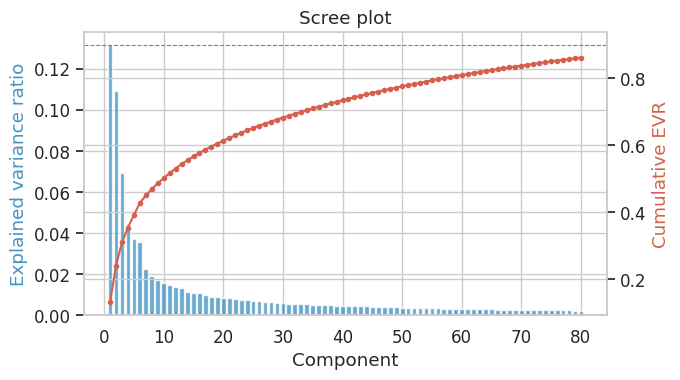

In [24]:
scree = bulk_pipe.decomposer_.scree_data()
fig, ax = plot_scree(scree, max_components=n_components); plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, f"{CANCER_TAG}_scree.pdf"), bbox_inches="tight"); plt.show()


In [25]:
adata_bulk_pp = bulk_pipe.preprocessor_.transform(adata_bulk)

sc_pipe = SingleCellPipeline(
    bulk_pipeline    = bulk_pipe,
    alignment_method = "moment_matching",
)
sc_pipe.fit(adata_bulk_pp, adata_sc)
adata_sc = sc_pipe.transform(adata_sc)

mut_prob_cols = [c for c in adata_sc.obs.columns if c.startswith("mutation_prob_")]
print(f"Inferred {len(mut_prob_cols)} mutation probability columns")


15:19:52 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.fit ===
15:19:52 | INFO     | scope.preprocessing.single_cell — SingleCellPreprocessor fitted.
15:19:52 | INFO     | scope.preprocessing.single_cell — QC filter: removed 4 / 3644 cells (3640 retained).
15:19:53 | INFO     | scope.utils.gene_utils — Gene universe: 13341 shared, 7189 bulk-only, 1588 sc-only
15:19:54 | INFO     | scope.preprocessing.alignment — BulkSCAligner fitted (method=moment_matching, n_genes=13341).
15:19:54 | INFO     | scope.pipeline.sc_pipeline — SingleCellPipeline.fit complete.
15:19:54 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.transform ===
15:19:54 | INFO     | scope.preprocessing.single_cell — QC filter: removed 4 / 3644 cells (3640 retained).
15:20:01 | WARNING  | scope.pipeline.sc_pipeline — 7189 / 20530 bulk genes absent from sc data (will be zero-padded).
15:20:13 | INFO     | scope.pipeline.sc_pipeline — Projected 3640 cells into 80-D latent space.
15:20:13 |

Inferred 15 mutation probability columns


/home/groups/precepts/ashforda/micromamba/envs/scope-dev/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
15:20:34 | INFO     | scope.visualization.embeddings — UMAP computed: 3640 cells → 2D.


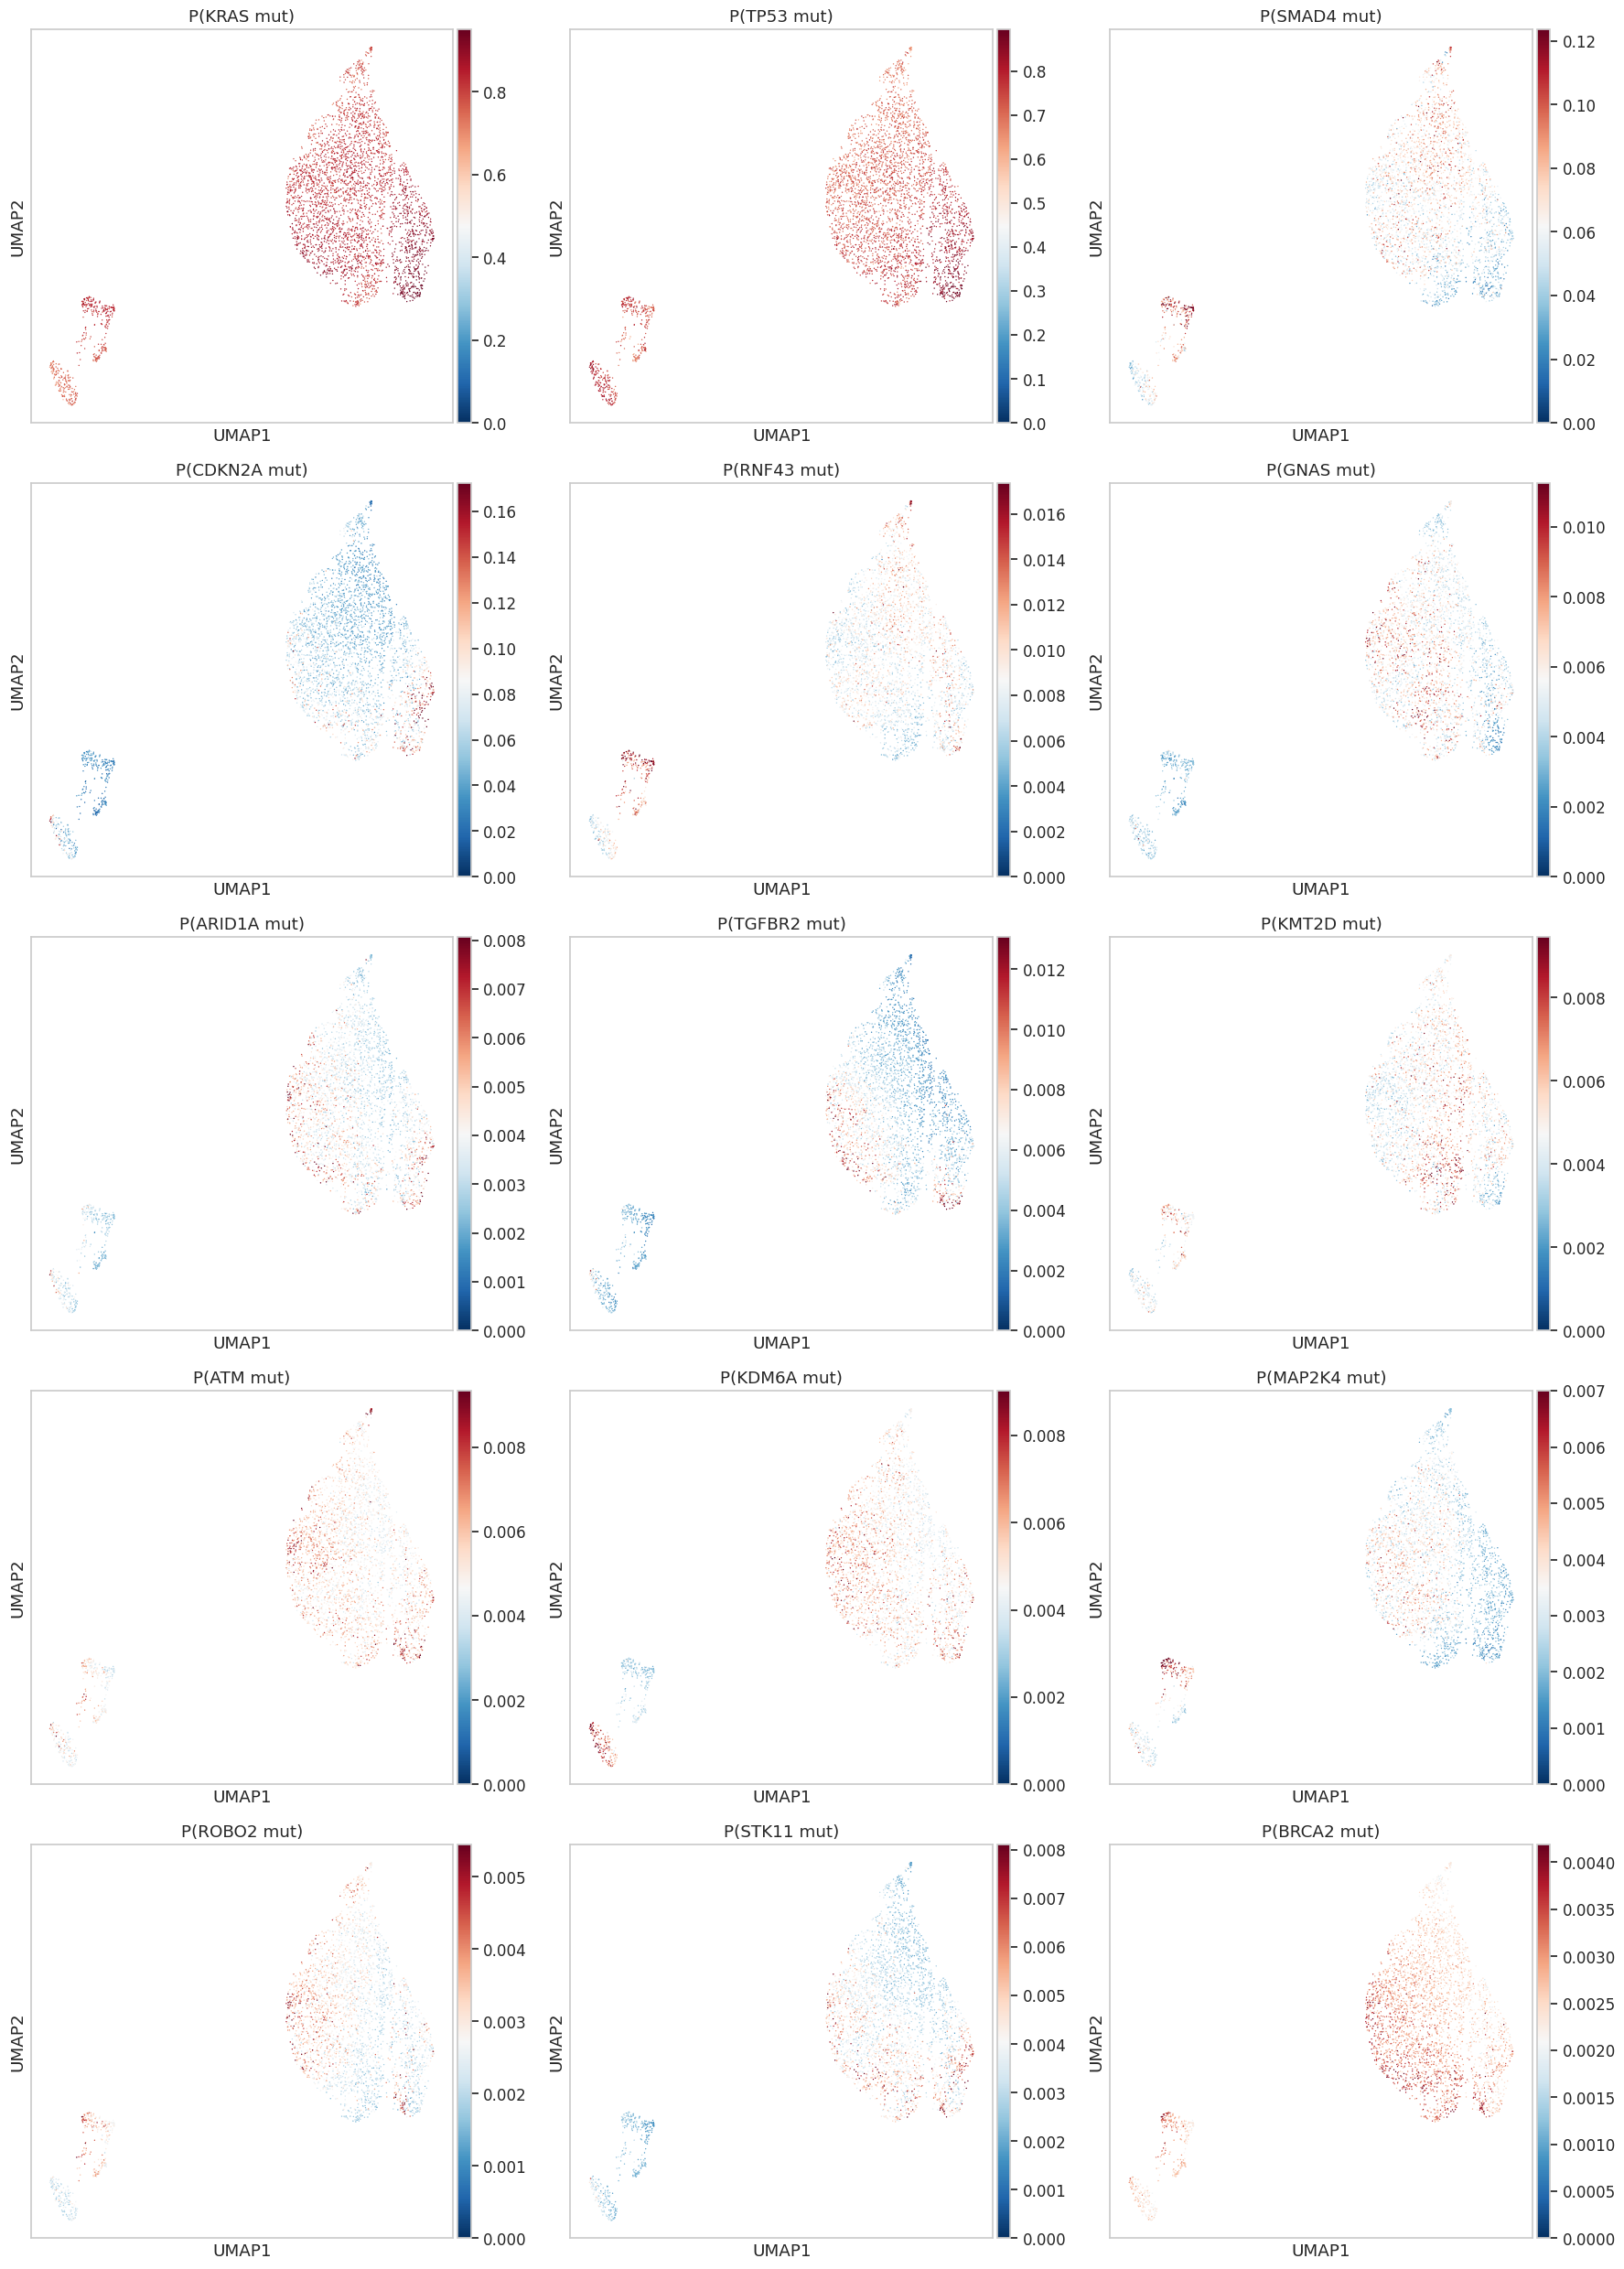

In [26]:
# -- UMAP on SVD latent embedding -----------------------------------------
adata_sc = compute_umap(adata_sc, obsm_key="X_svd")

top_muts = mutation_labels.sum().sort_values(ascending=False).index.tolist()
prob_cols = [f"mutation_prob_{g}" for g in top_muts
             if f"mutation_prob_{g}" in adata_sc.obs.columns]

# Cell type + top mutation UMAPs
ct_col = next((c for c in adata_sc.obs.columns
               if "type" in c.lower() or "celltype" in c.lower()
               or "cluster" in c.lower()), None)
if ct_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sc.pl.umap(adata_sc, color=ct_col, ax=axes[0], show=False, title="Cell type")
    sc.pl.umap(adata_sc, color=prob_cols[0] if prob_cols else ct_col,
               ax=axes[1], show=False, title=f"P({top_muts[0]} mut)")
    plt.tight_layout()
    fig.savefig(os.path.join(MODELS_DIR, f"{CANCER_TAG}_umap_overview.pdf"),
                bbox_inches="tight")
    plt.show()

# All mutation probability UMAPs
vmaxes = {c: max(float(np.percentile(adata_sc.obs[c].values, 99)), 0.0005)
          for c in prob_cols}
ncols = 3
nrows = int(np.ceil(len(prob_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()
for i, col in enumerate(prob_cols):
    gene = col.replace("mutation_prob_", "")
    sc.pl.umap(adata_sc, color=col, ax=axes[i], show=False,
               title=f"P({gene} mut)", vmin=0, vmax=vmaxes[col],
               cmap="RdBu_r", colorbar_loc="right", s=4)
for j in range(len(prob_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(MODELS_DIR, f"{CANCER_TAG}_mutation_probs_umap.pdf"),
            bbox_inches="tight")
plt.show()

# Heatmap: mean probability per cluster
if ct_col:
    fig, ax = plot_mutation_heatmap(adata_sc, cluster_key=ct_col, mutations=top_muts)
    fig.savefig(os.path.join(MODELS_DIR, f"{CANCER_TAG}_heatmap_{ct_col}.pdf"),
                bbox_inches="tight")
    plt.show()


In [28]:
print(adata_sc)


AnnData object with n_obs × n_vars = 3640 × 20530
    obs: 'sample', 'n_genes', 'mutation_prob_KRAS', 'mutation_prob_TP53', 'mutation_prob_CDKN2A', 'mutation_prob_SMAD4', 'mutation_prob_ARID1A', 'mutation_prob_RNF43', 'mutation_prob_KDM6A', 'mutation_prob_GNAS', 'mutation_prob_KMT2D', 'mutation_prob_MAP2K4', 'mutation_prob_TGFBR2', 'mutation_prob_ROBO2', 'mutation_prob_ATM', 'mutation_prob_BRCA2', 'mutation_prob_STK11'
    uns: 'scope_mutations', 'scope_decomposition', 'scope_n_components'
    obsm: 'X_svd', 'X_umap'


In [27]:
adata_sc.write_h5ad(os.path.join(MODELS_DIR, f"{CANCER_TAG}_sc_with_mutation_probs.h5ad"))
print(f"Saved h5ad -> {MODELS_DIR}")


Saved h5ad -> /home/groups/precepts/ashforda/scOPE_github_stuff/scOPE_overhaul/scOPE/data/../models/PAAD
